# Laboratorio 6 — CNN desde cero: costos y evaluación en test
Completa, para la **CNN desde cero**, las filas de la tabla de la sección 5:
parámetros, costo de inferencia, costo de entrenamiento, estimación de cómputo total y desempeño en **test**.

Usa los artefactos de `Lab6_CNN_desde_cero.ipynb` (`results_cnn.json` y `models/cnn_<iteración>.pt`). No reentrena nada.
El conjunto de test se evalúa **una sola vez**, únicamente con la mejor configuración según validación.

## 0. Configuración

In [1]:
import json
import platform
import subprocess
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             confusion_matrix, classification_report, ConfusionMatrixDisplay)

device = (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

def hardware_name():
    if device == "cuda":
        return torch.cuda.get_device_name(0)
    if platform.system() == "Darwin":
        chip = subprocess.run(["sysctl", "-n", "machdep.cpu.brand_string"],
                              capture_output=True, text=True).stdout.strip()
        return f"{chip} (GPU integrada, backend MPS)" if device == "mps" else chip
    return platform.processor() or platform.machine()

HW = hardware_name()
print(f"torch {torch.__version__} | device: {device} | hardware: {HW}")

with open("results_cnn.json") as f:
    SAVED = json.load(f)
BEST = SAVED["best"]
R = SAVED["results"][BEST]
print("Mejor configuración según validación:", BEST)

torch 2.8.0 | device: mps | hardware: Apple M5 (GPU integrada, backend MPS)
Mejor configuración según validación: ancha


## 1. Modelo

In [2]:
# Misma definición que en Lab6_CNN_desde_cero.ipynb (los notebooks no comparten código)
class CNN(nn.Module):
    def __init__(self, channels=(32, 64, 128), conv_dropout=0.0, fc_dropout=0.3,
                 fc_hidden=256, use_bn=True, n_classes=10):
        super().__init__()
        layers, c_in = [], 3
        for c_out in channels:
            for _ in range(2):
                layers.append(nn.Conv2d(c_in, c_out, 3, padding=1, bias=not use_bn))
                if use_bn:
                    layers.append(nn.BatchNorm2d(c_out))
                layers.append(nn.ReLU(inplace=True))
                c_in = c_out
            layers.append(nn.MaxPool2d(2))
            if conv_dropout > 0:
                layers.append(nn.Dropout2d(conv_dropout))
        self.features = nn.Sequential(*layers)
        spatial = 32 // (2 ** len(channels))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(c_in * spatial * spatial, fc_hidden),
            nn.BatchNorm1d(fc_hidden) if use_bn else nn.Identity(),
            nn.ReLU(inplace=True),
            nn.Dropout(fc_dropout),
            nn.Linear(fc_hidden, n_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

model = CNN(**R["config"]["model"])
model.load_state_dict(torch.load(f"models/cnn_{BEST}.pt", map_location="cpu"))
model = model.to(device).eval()

params_total = sum(p.numel() for p in model.parameters())
params_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
assert params_total == R["params_total"] and params_trainable == R["params_trainable"]
print(f"Parámetros totales: {params_total:,} | entrenables: {params_trainable:,}")

Parámetros totales: 2,198,218 | entrenables: 2,198,218


## 2. Costo de inferencia
**MACs** (multiply-accumulate) por imagen en un forward pass; **FLOPs ≈ 2 × MACs** (una multiplicación y una suma por MAC).
Se cuentan las capas `Conv2d` y `Linear` con un contador propio (hooks), que es lo que domina el costo, y se contrasta con `fvcore`
(que también cuenta BatchNorm y otras operaciones menores).

In [3]:
def count_macs(model, input_size=(1, 3, 32, 32)):
    macs = {"total": 0}
    per_layer = []
    def hook(name):
        def fn(m, inp, out):
            if isinstance(m, nn.Conv2d):
                k = m.kernel_size[0] * m.kernel_size[1] * (m.in_channels // m.groups)
                mac = out.numel() // out.shape[0] * k          # por imagen
            else:  # Linear
                mac = m.in_features * m.out_features
            macs["total"] += mac
            per_layer.append((name, type(m).__name__, mac))
        return fn
    hooks = [m.register_forward_hook(hook(n)) for n, m in model.named_modules()
             if isinstance(m, (nn.Conv2d, nn.Linear))]
    cpu_model = CNN(**R["config"]["model"]); cpu_model.load_state_dict(model.state_dict()); cpu_model.eval()
    # (se corre en CPU con un modelo copia para no depender del dispositivo)
    for h in hooks: h.remove()
    hooks = [m.register_forward_hook(hook(n)) for n, m in cpu_model.named_modules()
             if isinstance(m, (nn.Conv2d, nn.Linear))]
    with torch.no_grad():
        cpu_model(torch.zeros(input_size))
    for h in hooks: h.remove()
    return macs["total"], per_layer

MACS, per_layer = count_macs(model)
FLOPS_FWD = 2 * MACS
print(f"MACs por imagen:  {MACS:,}  (~{MACS/1e6:.2f} M)")
print(f"FLOPs por imagen: {FLOPS_FWD:,}  (~{FLOPS_FWD/1e6:.2f} M)")
display(pd.DataFrame(per_layer, columns=["capa", "tipo", "MACs"]).assign(
    pct=lambda d: (d["MACs"] / d["MACs"].sum() * 100).round(1)))

# Verificación cruzada con fvcore (cuenta "flops" = MACs; ignora ReLU/pool, incluye BN)
try:
    from fvcore.nn import FlopCountAnalysis
    cpu_model = CNN(**R["config"]["model"]); cpu_model.load_state_dict(model.state_dict()); cpu_model.eval()
    fv = FlopCountAnalysis(cpu_model, torch.zeros(1, 3, 32, 32))
    fv.unsupported_ops_warnings(False); fv.uncalled_modules_warnings(False)
    print(f"fvcore (MACs): {fv.total():,}  | diferencia vs. contador propio: {fv.total() - MACS:+,}")
except Exception as e:
    print("fvcore no disponible:", e)

MACs por imagen:  153,815,552  (~153.82 M)
FLOPs por imagen: 307,631,104  (~307.63 M)


,capa,tipo,MACs,pct
0,features.0,Conv2d,1769472,1.2
1,features.3,Conv2d,37748736,24.5
2,features.8,Conv2d,18874368,12.3
3,features.11,Conv2d,37748736,24.5
4,features.16,Conv2d,18874368,12.3
5,features.19,Conv2d,37748736,24.5
6,classifier.1,Linear,1048576,0.7
7,classifier.5,Linear,2560,0.0


fvcore (MACs): 154,274,816  | diferencia vs. contador propio: +459,264


### Latencia en GPU
Promedio por imagen con `torch.cuda/mps.synchronize()` (las GPU son asíncronas), tras un *warm-up*.
Se reportan dos casos: **batch = 1** (latencia pura) y **batch = 128** (throughput, tiempo por imagen).

In [4]:
def sync():
    if device == "cuda": torch.cuda.synchronize()
    elif device == "mps": torch.mps.synchronize()

@torch.no_grad()
def latency_ms_per_image(model, batch, warmup=50, iters=300):
    x = torch.randn(batch, 3, 32, 32, device=device)
    for _ in range(warmup):
        model(x)
    sync()
    times = []
    for _ in range(iters):
        t0 = time.perf_counter(); model(x); sync()
        times.append((time.perf_counter() - t0) * 1000 / batch)
    return float(np.mean(times)), float(np.std(times))

lat1, lat1_sd = latency_ms_per_image(model, batch=1)
lat128, lat128_sd = latency_ms_per_image(model, batch=128, iters=100)
print(f"Latencia batch=1:   {lat1:.3f} ± {lat1_sd:.3f} ms/imagen")
print(f"Latencia batch=128: {lat128:.4f} ± {lat128_sd:.4f} ms/imagen  ({1000/lat128:,.0f} img/s)")

Latencia batch=1:   1.372 ± 1.852 ms/imagen
Latencia batch=128: 0.1059 ± 0.0032 ms/imagen  (9,446 img/s)


## 3. Costo de entrenamiento
Medido durante el entrenamiento (`results_cnn.json`). *Nota:* la memoria pico en MPS es una aproximación (memoria reservada al driver) y es casi igual entre modelos; en CUDA sería `max_memory_allocated()`.

In [5]:
h = R["history"]
best_epoch = R["best_epoch"]
train_cost = {
    "tiempo por epoch (media, s)": R["mean_epoch_time"],
    "epochs entrenados": len(h["train_loss"]),
    "epochs hasta la mejor val acc": best_epoch,
    "tiempo hasta la mejor val acc (s)": R["time_to_best"],
    "tiempo total de entrenamiento (s)": R["total_time"],
    "memoria pico (MB, aprox. MPS)": R["peak_mem_mb"],
}
display(pd.Series(train_cost, name="valor").to_frame())

,valor
"tiempo por epoch (media, s)",32.840530
epochs entrenados,25.000000
epochs hasta la mejor val acc,21.000000
tiempo hasta la mejor val acc (s),718.791855
tiempo total de entrenamiento (s),847.096272
"memoria pico (MB, aprox. MPS)",1114.562500


## 4. Estimación del cómputo total de entrenamiento (FLOPs)
Por imagen, un paso de entrenamiento cuesta ≈ **3 × el forward**: 1× forward + ≈ 2× backward
(gradiente respecto a las activaciones + gradiente respecto a los pesos). En la CNN desde cero **todas** las capas hacen backward.

$$\text{FLOPs}_{train} \approx 3 \times \text{FLOPs}_{fwd} \times N_{imgs} \times N_{epochs}$$

Se excluyen las pasadas de validación y la augmentation (que corre en CPU). Se reporta con los epochs hasta el mejor y con todos los entrenados.

In [6]:
def train_flops(flops_fwd, n_images, epochs, backward_fraction=1.0):
    # backward_fraction: proporción del forward cuyo backward se calcula (1.0 = toda la red)
    return flops_fwd * n_images * epochs * (1 + 2 * backward_fraction)

N_TRAIN = 45_000
flops_best = train_flops(FLOPS_FWD, N_TRAIN, best_epoch)
flops_all = train_flops(FLOPS_FWD, N_TRAIN, len(h["train_loss"]))
print(f"Hasta el mejor epoch ({best_epoch}): {flops_best:.3e} FLOPs  (~{flops_best/1e12:.2f} TFLOPs)")
print(f"Todos los epochs ({len(h['train_loss'])}):    {flops_all:.3e} FLOPs  (~{flops_all/1e12:.2f} TFLOPs)")
print(f"Throughput efectivo: {flops_all / R['total_time'] / 1e9:.1f} GFLOP/s (sobre el tiempo total, incluye validación y carga de datos)")

Hasta el mejor epoch (21): 8.721e+14 FLOPs  (~872.13 TFLOPs)
Todos los epochs (25):    1.038e+15 FLOPs  (~1038.25 TFLOPs)
Throughput efectivo: 1225.7 GFLOP/s (sobre el tiempo total, incluye validación y carga de datos)


## 5. Desempeño en test (única evaluación)
Mejor configuración según validación → evaluación **una vez** sobre los 10,000 imágenes de test. Se generan las métricas y la matriz de confusión.

In [7]:
train_raw = datasets.CIFAR10("data", train=True, download=False)
X = train_raw.data.astype(np.float64) / 255.0
CIFAR_MEAN, CIFAR_STD = X.mean(axis=(0, 1, 2)), X.std(axis=(0, 1, 2)); del X
eval_tf = transforms.Compose([transforms.ToTensor(),
                              transforms.Normalize(CIFAR_MEAN.tolist(), CIFAR_STD.tolist())])
test_ds = datasets.CIFAR10("data", train=False, download=False, transform=eval_tf)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False, num_workers=0)
CLASSES = test_ds.classes

@torch.no_grad()
def predict(model, loader):
    model.eval(); preds, labels = [], []
    for x, y in loader:
        preds.append(model(x.to(device)).argmax(1).cpu()); labels.append(y)
    return torch.cat(preds).numpy(), torch.cat(labels).numpy()

preds, labels = predict(model, test_loader)          # <- única evaluación en test
p, r, f1, _ = precision_recall_fscore_support(labels, preds, average="macro", zero_division=0)
TEST = {"acc": accuracy_score(labels, preds), "precision": p, "recall": r, "f1": f1}
print(f"Test ({BEST}) — " + " | ".join(f"{k}: {v:.4f}" for k, v in TEST.items()))
print(f"Validación ({BEST}) — acc: {R['val_best']['acc']:.4f} | f1: {R['val_best']['f1']:.4f}")
print()
print(classification_report(labels, preds, target_names=CLASSES, digits=3))

Test (ancha) — acc: 0.9018 | precision: 0.9015 | recall: 0.9018 | f1: 0.9015
Validación (ancha) — acc: 0.9062 | f1: 0.9059

              precision    recall  f1-score   support

    airplane      0.910     0.899     0.904      1000
  automobile      0.964     0.960     0.962      1000
        bird      0.895     0.857     0.875      1000
         cat      0.801     0.773     0.787      1000
        deer      0.885     0.915     0.900      1000
         dog      0.843     0.851     0.847      1000
        frog      0.908     0.937     0.922      1000
       horse      0.929     0.930     0.930      1000
        ship      0.940     0.946     0.943      1000
       truck      0.941     0.950     0.945      1000

    accuracy                          0.902     10000
   macro avg      0.901     0.902     0.902     10000
weighted avg      0.901     0.902     0.902     10000



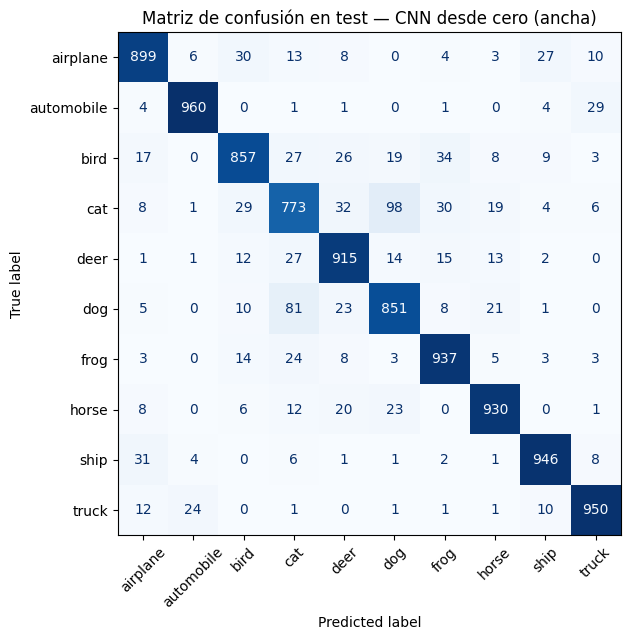

,real,predicha,errores
0,cat,dog,98
1,dog,cat,81
2,bird,frog,34
3,cat,deer,32
4,ship,airplane,31


In [8]:
cm = confusion_matrix(labels, preds)
fig, ax = plt.subplots(figsize=(7.5, 6.5))
ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(ax=ax, cmap="Blues", xticks_rotation=45, colorbar=False)
ax.set_title(f"Matriz de confusión en test — CNN desde cero ({BEST})")
plt.tight_layout(); plt.savefig("cm_cnn_test.png", dpi=150); plt.show()

# Pares de clases más confundidos (fuera de la diagonal)
off = cm.copy(); np.fill_diagonal(off, 0)
top = np.dstack(np.unravel_index(np.argsort(-off.ravel())[:5], off.shape))[0]
display(pd.DataFrame([{"real": CLASSES[i], "predicha": CLASSES[j], "errores": int(off[i, j])} for i, j in top]))

## 6. Resumen para la tabla comparativa (sección 5 del enunciado)

In [9]:
resumen = {
    "modelo": "CNN desde cero",
    "iteración": BEST,
    "hardware": HW,
    "params_totales": params_total,
    "params_entrenables": params_trainable,
    "macs_por_imagen": MACS,
    "flops_por_imagen": FLOPS_FWD,
    "latencia_ms_batch1": lat1,
    "latencia_ms_por_imagen_batch128": lat128,
    "s_por_epoch": R["mean_epoch_time"],
    "epochs_hasta_mejor": best_epoch,
    "tiempo_total_s": R["total_time"],
    "mem_pico_mb_mps_aprox": R["peak_mem_mb"],
    "flops_entrenamiento_hasta_mejor": flops_best,
    "flops_entrenamiento_todos_epochs": flops_all,
    "test_acc": TEST["acc"], "test_precision": TEST["precision"],
    "test_recall": TEST["recall"], "test_f1": TEST["f1"],
    "val_acc": R["val_best"]["acc"], "val_f1": R["val_best"]["f1"],
}
with open("resumen_cnn.json", "w") as f:
    json.dump(resumen, f, indent=2)
display(pd.Series(resumen, name="CNN desde cero").to_frame())

,CNN desde cero
modelo,CNN desde cero
iteración,ancha
hardware,"Apple M5 (GPU integrada, backend MPS)"
params_totales,2198218
params_entrenables,2198218
macs_por_imagen,153815552
flops_por_imagen,307631104
latencia_ms_batch1,1.37191
latencia_ms_por_imagen_batch128,0.105865
s_por_epoch,32.84053
